Dataset Loaded Successfully
                event_time event_type  product_id   category_id  \
0  2019-11-01 00:00:00 UTC       view     1003461  2.053010e+18   
1  2019-11-01 00:00:00 UTC       view     5000088  2.053010e+18   
2  2019-11-01 00:00:01 UTC       view    17302664  2.053010e+18   
3  2019-11-01 00:00:01 UTC       view     3601530  2.053010e+18   
4  2019-11-01 00:00:01 UTC       view     1004775  2.053010e+18   

               category_code   brand   price    user_id  \
0     electronics.smartphone  xiaomi  489.07  520088904   
1  appliances.sewing_machine  janome  293.65  530496790   
2                        NaN   creed   28.31  561587266   
3  appliances.kitchen.washer      lg  712.87  518085591   
4     electronics.smartphone  xiaomi  183.27  558856683   

                           user_session  
0  4d3b30da-a5e4-49df-b1a8-ba5943f1dd33  
1  8e5f4f83-366c-4f70-860e-ca7417414283  
2  755422e7-9040-477b-9bd2-6a6e8fd97387  
3  3bfb58cd-7892-48cc-8020-2f17e6de6e7f  
4  3

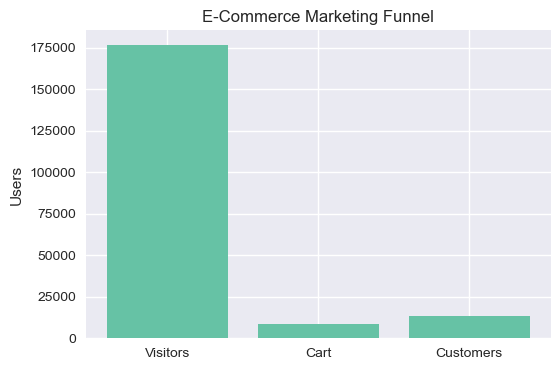


Top Selling Products
product_id
1004856    809
1004767    514
1005115    446
1004833    389
1002544    309
4804056    300
1004870    242
1004249    231
1005105    216
1004836    202
Name: count, dtype: int64


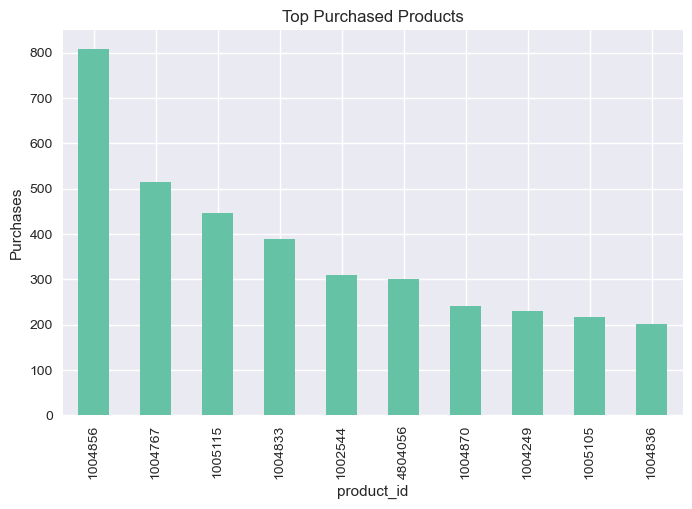


Top Brands
brand
samsung     4370
apple       3568
xiaomi      1327
huawei       502
cordiant     378
oppo         307
lucente      269
lg           213
nokian       190
triangle     178
Name: count, dtype: int64


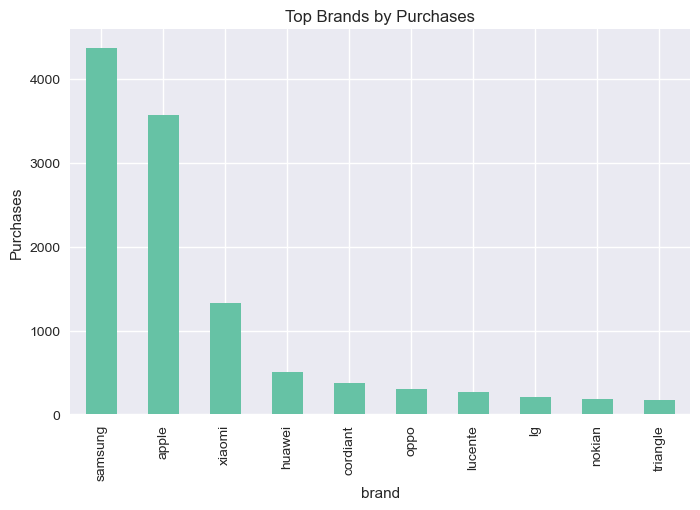

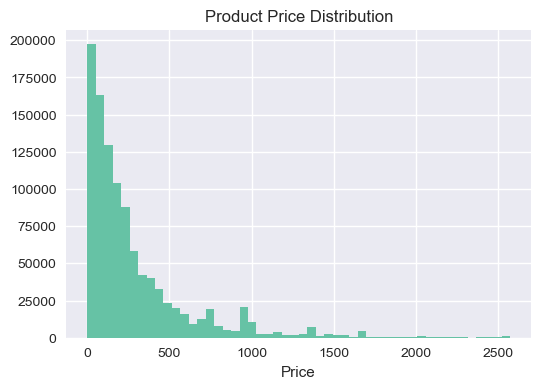

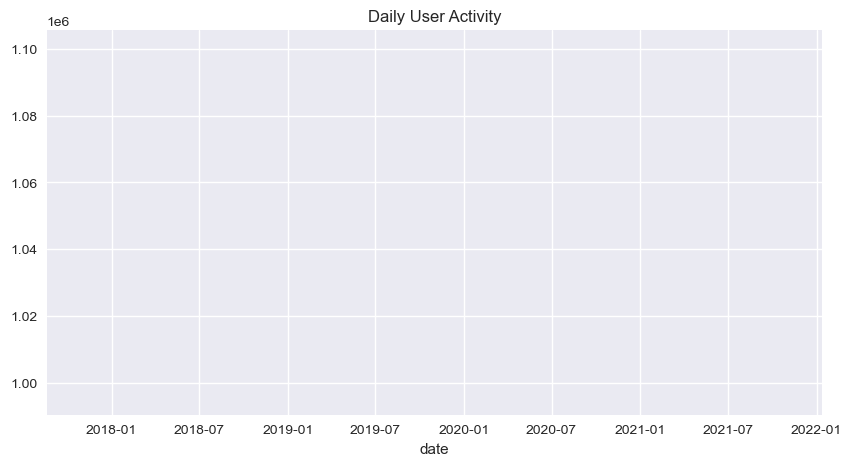


Top Categories
category_code
electronics.smartphone              8499
electronics.audio.headphone          754
electronics.video.tv                 495
electronics.clocks                   406
appliances.kitchen.washer            366
computers.notebook                   324
appliances.kitchen.refrigerators     263
appliances.environment.vacuum        263
electronics.tablet                   119
computers.desktop                    115
Name: count, dtype: int64


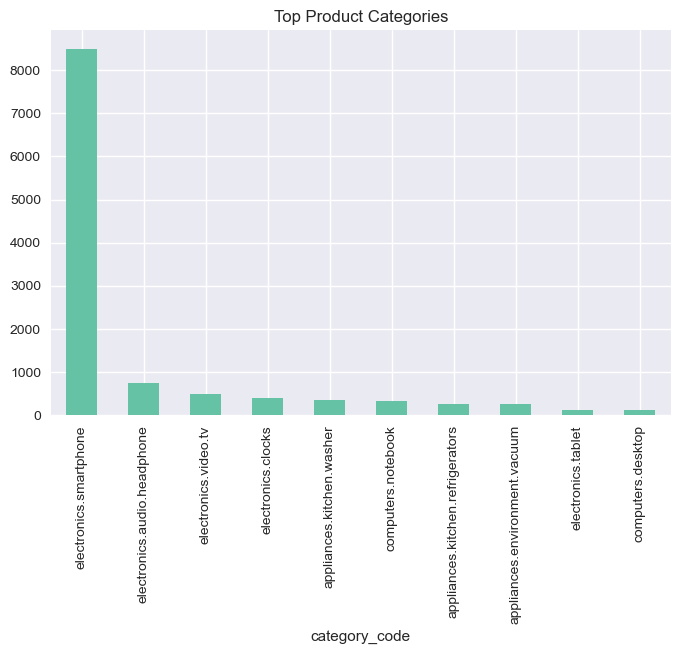


--- KEY INSIGHTS ---
Total Visitors: 176624
Total Cart Users: 8642
Total Customers: 13635
Best performing brand: samsung
Best category: electronics.smartphone

--- RECOMMENDATIONS ---

1. Improve product pages to increase View → Cart conversion.
2. Offer discounts to users who abandon carts.
3. Promote top selling brands more aggressively.
4. Retarget users who viewed products but didn't purchase.
5. Optimize pricing strategy based on price distribution.



In [6]:
# =========================================================
# MARKETING FUNNEL & CONVERSION ANALYSIS
# Using E-Commerce User Behavior Dataset
# =========================================================

# ---------------------------------------------------------
# 1. IMPORT LIBRARIES
# ---------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 2. LOAD DATASET
# ---------------------------------------------------------

df = pd.read_csv("marketing_funnel_data.csv")

print("Dataset Loaded Successfully")
print(df.head())

# ---------------------------------------------------------
# 3. DATA CLEANING
# ---------------------------------------------------------

# Convert event_time to datetime
df['event_time'] = pd.to_datetime(df['event_time'])

# Remove duplicates
df = df.drop_duplicates()

# Remove missing user_id
df = df.dropna(subset=['user_id'])

print("\nDataset Shape:", df.shape)

# ---------------------------------------------------------
# 4. FUNNEL STAGE CALCULATION
# ---------------------------------------------------------

# Stage 1: Visitors (view event)
visitors = df[df['event_type'] == 'view']['user_id'].nunique()

# Stage 2: Cart users
cart_users = df[df['event_type'] == 'cart']['user_id'].nunique()

# Stage 3: Purchasers
customers = df[df['event_type'] == 'purchase']['user_id'].nunique()

print("\n--- Funnel Stages ---")
print("Visitors:", visitors)
print("Cart Users:", cart_users)
print("Customers:", customers)

# ---------------------------------------------------------
# 5. CONVERSION RATES
# ---------------------------------------------------------

view_to_cart = (cart_users / visitors) * 100
cart_to_purchase = (customers / cart_users) * 100
view_to_purchase = (customers / visitors) * 100

print("\n--- Conversion Rates ---")
print("View → Cart:", round(view_to_cart,2), "%")
print("Cart → Purchase:", round(cart_to_purchase,2), "%")
print("View → Purchase:", round(view_to_purchase,2), "%")

# ---------------------------------------------------------
# 6. FUNNEL DROP-OFF
# ---------------------------------------------------------

drop_view = visitors - cart_users
drop_cart = cart_users - customers

print("\n--- Drop Off ---")
print("Users lost before cart:", drop_view)
print("Users lost before purchase:", drop_cart)

# ---------------------------------------------------------
# 7. FUNNEL VISUALIZATION
# ---------------------------------------------------------

stages = ['Visitors','Cart','Customers']
values = [visitors,cart_users,customers]

plt.figure(figsize=(6,4))
plt.bar(stages, values)

plt.title("E-Commerce Marketing Funnel")
plt.ylabel("Users")

plt.show()

# ---------------------------------------------------------
# 8. TOP PRODUCTS ANALYSIS
# ---------------------------------------------------------

top_products = df[df['event_type']=='purchase']['product_id'].value_counts().head(10)

print("\nTop Selling Products")
print(top_products)

plt.figure(figsize=(8,5))
top_products.plot(kind='bar')

plt.title("Top Purchased Products")
plt.ylabel("Purchases")

plt.show()

# ---------------------------------------------------------
# 9. TOP BRANDS ANALYSIS
# ---------------------------------------------------------

top_brands = df[df['event_type']=='purchase']['brand'].value_counts().head(10)

print("\nTop Brands")
print(top_brands)

plt.figure(figsize=(8,5))
top_brands.plot(kind='bar')

plt.title("Top Brands by Purchases")
plt.ylabel("Purchases")

plt.show()

# ---------------------------------------------------------
# 10. PRICE DISTRIBUTION
# ---------------------------------------------------------

plt.figure(figsize=(6,4))
df['price'].hist(bins=50)

plt.title("Product Price Distribution")
plt.xlabel("Price")

plt.show()

# ---------------------------------------------------------
# 11. TIME ANALYSIS
# ---------------------------------------------------------

df['date'] = df['event_time'].dt.date

daily_events = df.groupby('date')['event_type'].count()

plt.figure(figsize=(10,5))
daily_events.plot()

plt.title("Daily User Activity")

plt.show()

# ---------------------------------------------------------
# 12. CATEGORY PERFORMANCE
# ---------------------------------------------------------

top_categories = df[df['event_type']=='purchase']['category_code'].value_counts().head(10)

print("\nTop Categories")
print(top_categories)

plt.figure(figsize=(8,5))
top_categories.plot(kind='bar')

plt.title("Top Product Categories")

plt.show()

# ---------------------------------------------------------
# 13. KEY BUSINESS INSIGHTS
# ---------------------------------------------------------

print("\n--- KEY INSIGHTS ---")

print(f"Total Visitors: {visitors}")
print(f"Total Cart Users: {cart_users}")
print(f"Total Customers: {customers}")

best_brand = top_brands.index[0]
print("Best performing brand:", best_brand)

best_category = top_categories.index[0]
print("Best category:", best_category)

# ---------------------------------------------------------
# 14. BUSINESS RECOMMENDATIONS
# ---------------------------------------------------------

print("\n--- RECOMMENDATIONS ---")

print("""
1. Improve product pages to increase View → Cart conversion.
2. Offer discounts to users who abandon carts.
3. Promote top selling brands more aggressively.
4. Retarget users who viewed products but didn't purchase.
5. Optimize pricing strategy based on price distribution.
""")